<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula01a_California_Housing_Prices_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)
print(X.shape)
print(y.shape)
print(f"Number of classes: {len(set(y))}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")

(150, 4)
(150,)
Number of classes: 3
Number of features: 4
Number of samples: 150


In [5]:
from sklearn.datasets import fetch_california_housing
X, y = fetch_california_housing(return_X_y=True)
print(X.shape)
print(y.shape)
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Feture names: {fetch_california_housing().feature_names}")

(20640, 8)
(20640,)
Number of features: 8
Number of samples: 20640
Feture names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


In [6]:
print(type(X))
print(type(y))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [7]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [9]:
print(df.describe())

             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308     32.54000

<Axes: >

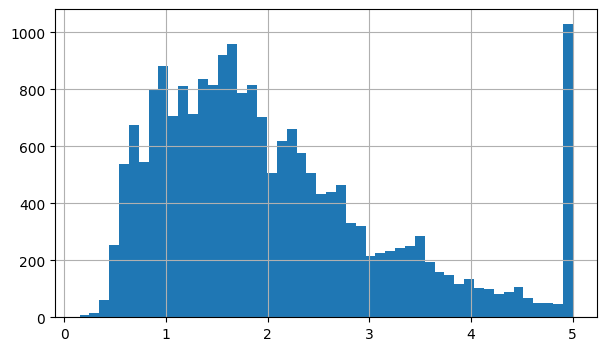

In [12]:
df['MedHouseVal'].hist(bins=50, figsize=(7,4))

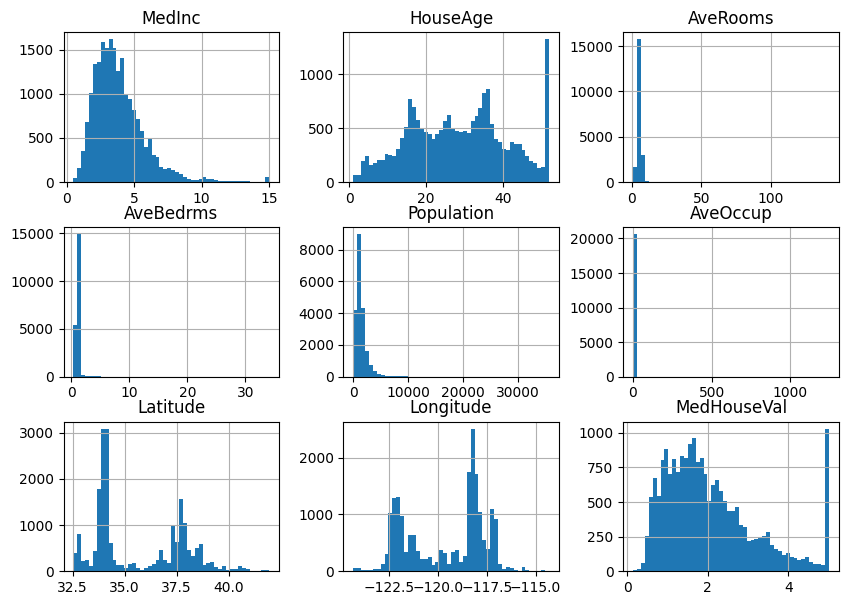

In [14]:
_ = df.hist(bins=50, figsize=(10,7))

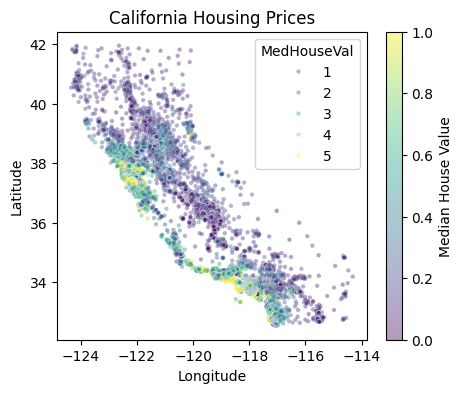

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(5,4))
scatter = sns.scatterplot(data=df, x='Longitude', y='Latitude',
                          hue='MedHouseVal',
                          s=10, alpha=0.4,
                          palette = 'viridis',
                          ax=ax)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('California Housing Prices')
cbar = fig.colorbar(scatter.collections[0], ax=ax, label="Median House Value")
cbar.set_label('Median House Value')
plt.show()

<Axes: >

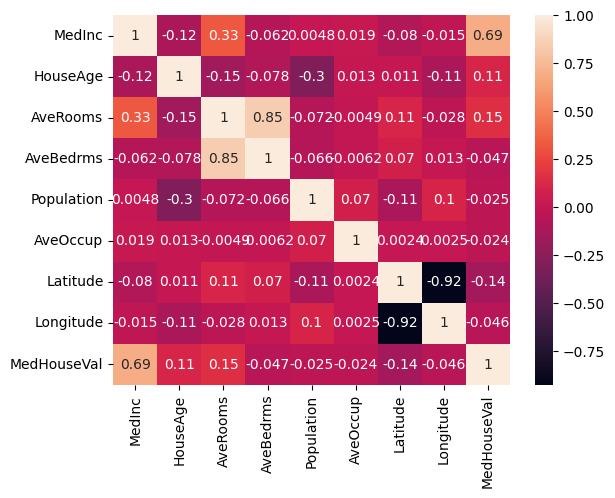

In [22]:
import seaborn as sns
corr = df.corr()
sns.heatmap(corr, annot=True)

In [25]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)

(16512, 8)
(4128, 8)


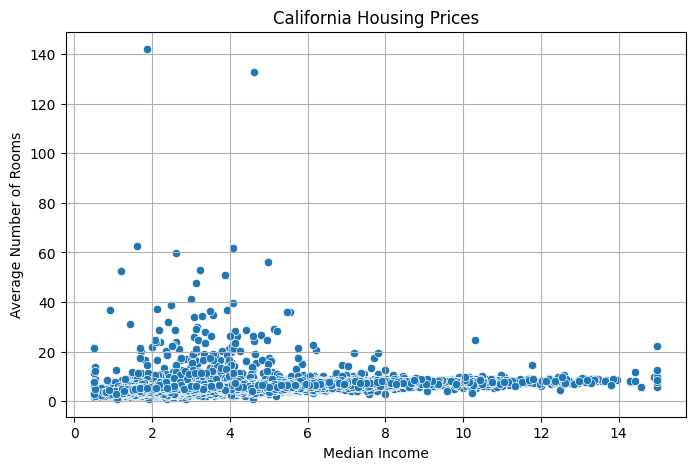

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='MedInc', y='AveRooms')
plt.xlabel('Median Income')
plt.ylabel('Average Number of Rooms')
plt.title('California Housing Prices')
plt.grid(True)
plt.show()

In [27]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [28]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [29]:
y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251])

In [30]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test, y_pred)
print(f"RMSE: {rmse}")

RMSE: 0.7455813830127763


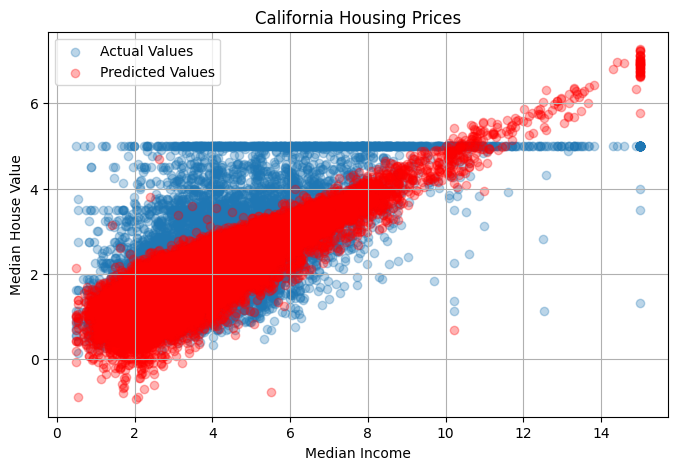

In [32]:
import matplotlib.pyplot as plt

y_train_pred = model.predict(X_train_scaled)

plt.figure(figsize=(8, 5))
plt.scatter(X_train[:, 0], y_train, label='Actual Values', alpha=0.3)
plt.scatter(X_train[:, 0], y_train_pred, label='Predicted Values',
            color='red', alpha=0.3)
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.title('California Housing Prices')
plt.legend()
plt.grid(True)
plt.show()
